<a href="https://colab.research.google.com/github/ranafikriyeak/MSc-Research/blob/main/case_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install uv
!pip install optuna
!uv pip install --system -r /content/drive/MyDrive/code/requirements-gpu.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.1/20.1 MB 60.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 14.5 MB/s eta 0:00:00
Using Python 3.13.15 environment at: /usr
  × No solution found when resolving dependencies:
  ╰─▶ Because ml-dtypes==0.5.4 depends on numpy>=2.1.0 and you require
      ml-dtypes==0.5.4, we can conclude that you require numpy>=2.1.0.
      And because you require numpy>=2.0,<2.1, we can conclude that your
      requirements are unsatisfiable.


In [3]:
!pip install --upgrade jax jaxlib equinox diffrax optax optimistix

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.9/87.9 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.8/185.8 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.7/199.7 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 403.0/403.0 kB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 8.8 MB/s eta 0:00:00
  Attempting uninstall: jaxlib
    Found existing installation: jaxlib 0.8.2
    Uninstalling jaxlib-0.8.2:
      Successfully uninstalled jaxlib-0.8.2
  Attempting uninstall: jax
    Found existing installation: jax 0.8.2
    Uninstalling jax-0.8.2:
      Successfully uninstalled jax-0.8.2
  Attempting uninstall: optax
    Found existing installation: optax 0.2.4
    Uninstalling optax-0.2.4:
      Successfully uninstalled optax-0.2.4
  Attempting uninstall: equinox
    Found existing installation: equinox 0.13.2
   

In [6]:
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import jax.random as jr
import equinox as eqx
import optax
import optuna
import optimistix as optx
import matplotlib.pyplot as plt
from diffrax import diffeqsolve, ODETerm, Kvaerno5, Tsit5, SaveAt, PIDController
import time
import numpy as np

import sys
repo_root = "/content/constrained-nodes"
sys.path.insert(0, repo_root)
repo_root = '/content/drive/MyDrive/code'
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)
from batch_reactor import batch

Generating datasets for all 4 conditions...
  0noise_sameIC: noise=0%, IC spread=0%
  2noise_sameIC: noise=2%, IC spread=0%
  2noise_diffIC: noise=2%, IC spread=40%
  0noise_diffIC: noise=0%, IC spread=40%

Architecture used for ALL 12 models (fixed, no search): width=64, depth=3, lr=1.00e-03

CONDITION: 0noise_sameIC  (noise=0%, IC spread=0%)
  [0noise_sameIC / Baseline] checkpoint found, skipping training.
  [0noise_sameIC / PtI] checkpoint found, skipping training.
  [0noise_sameIC / ItP] checkpoint found, skipping training.

CONDITION: 2noise_sameIC  (noise=2%, IC spread=0%)
  [2noise_sameIC / Baseline] checkpoint found, skipping training.
  [2noise_sameIC / PtI] checkpoint found, skipping training.
  [2noise_sameIC / ItP] checkpoint found, skipping training.

CONDITION: 2noise_diffIC  (noise=2%, IC spread=40%)
  [2noise_diffIC / Baseline] checkpoint found, skipping training.
  [2noise_diffIC / PtI] checkpoint found, skipping training.
  [2noise_diffIC / ItP] checkpoint found, skip

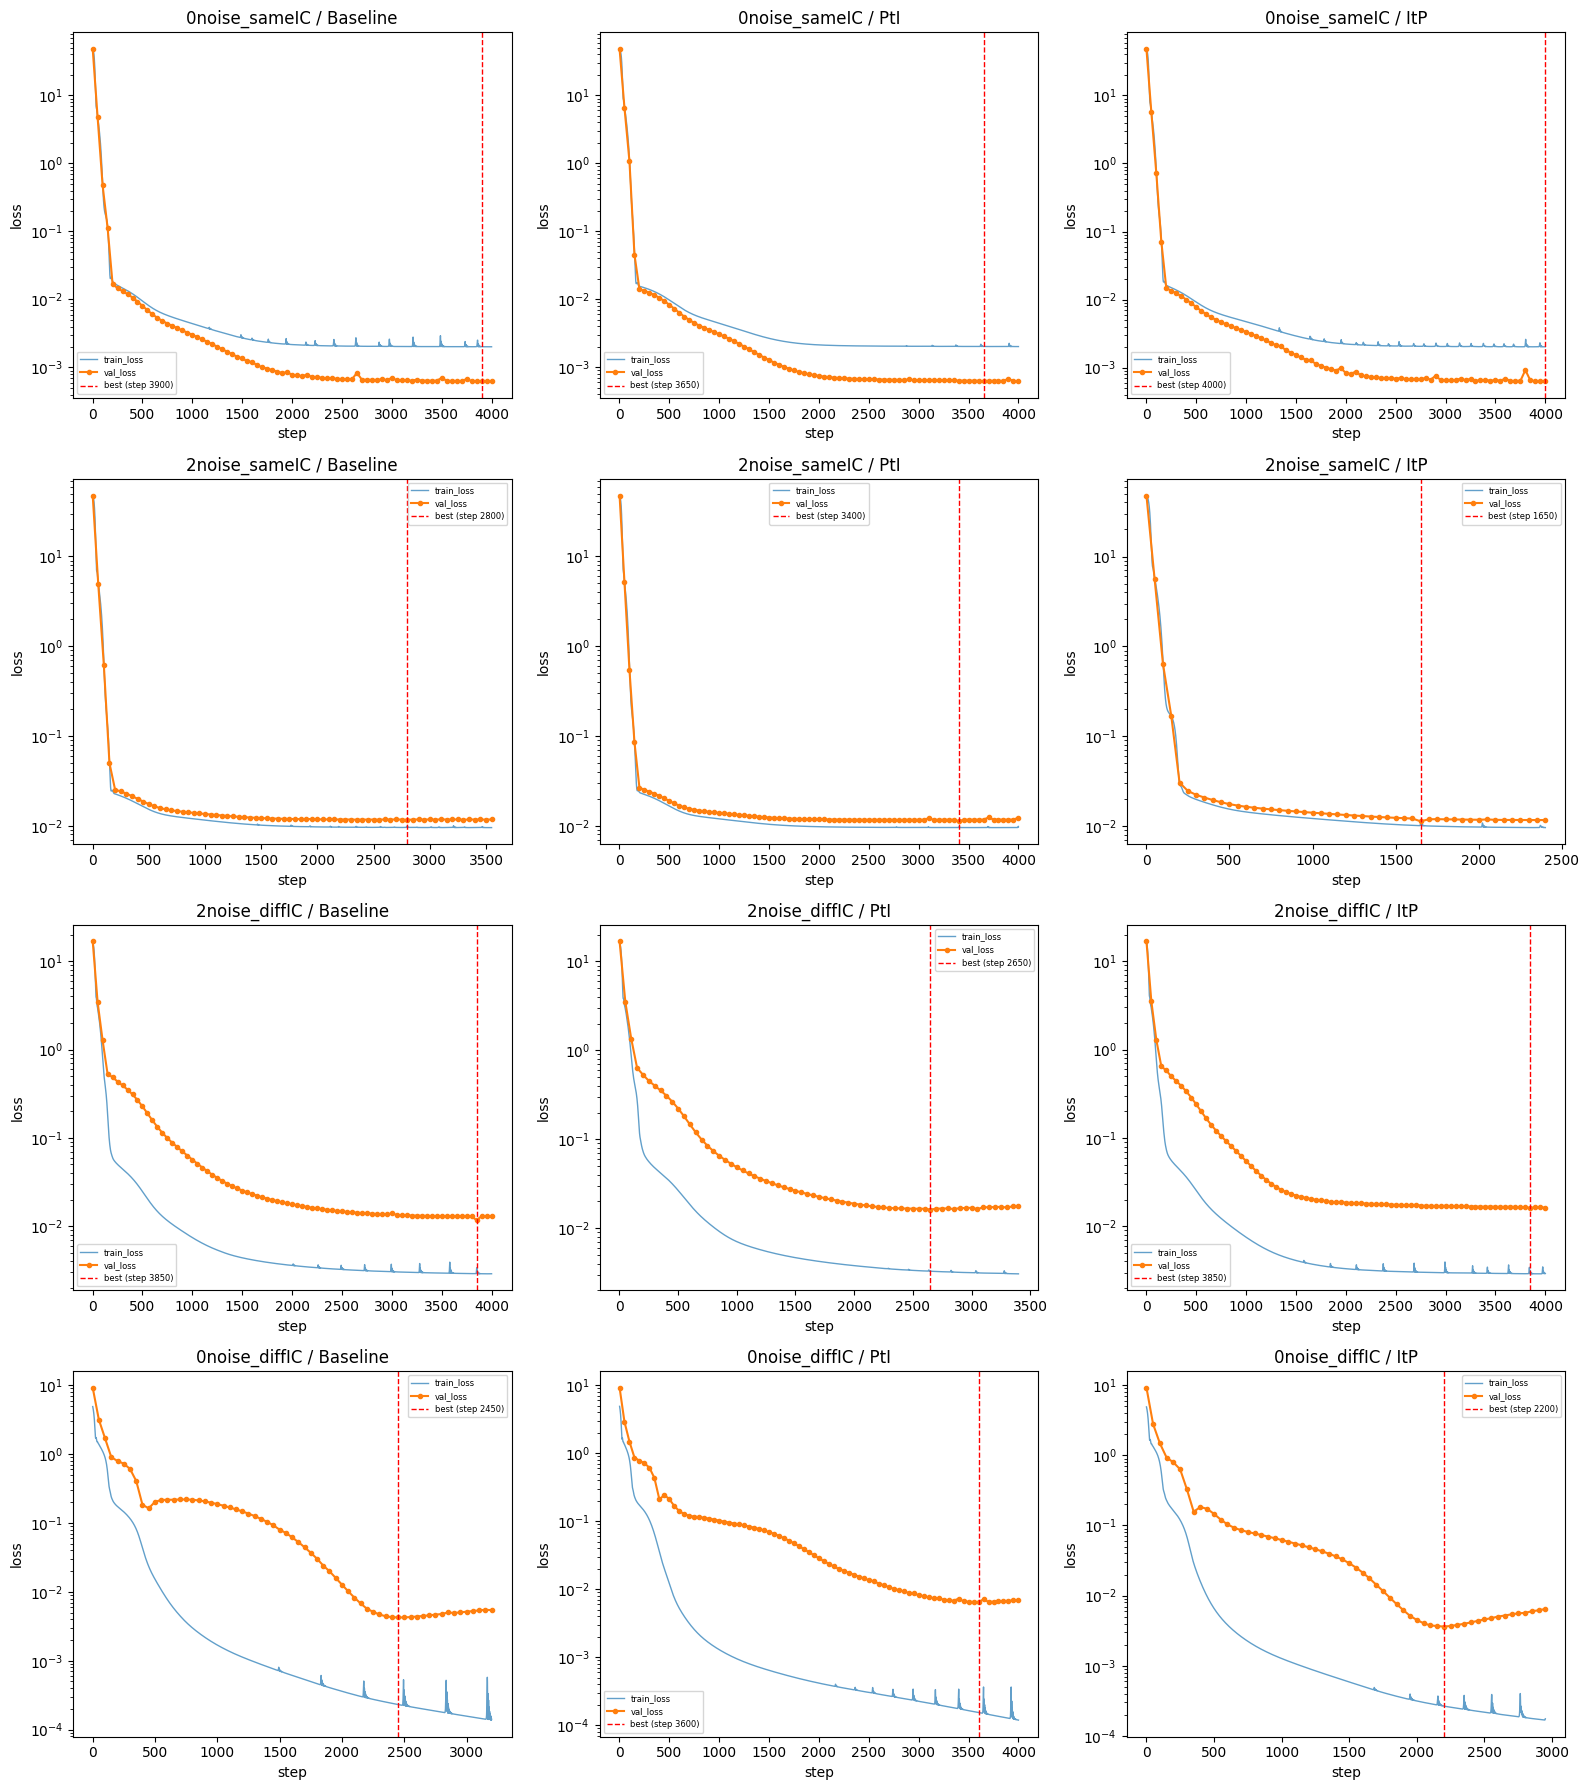

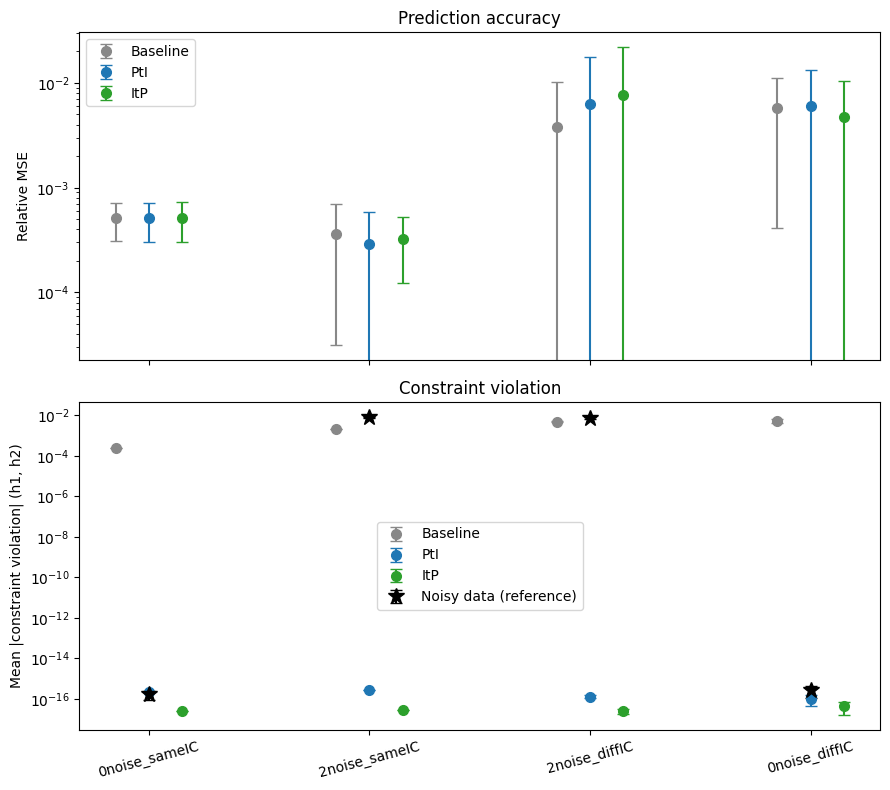

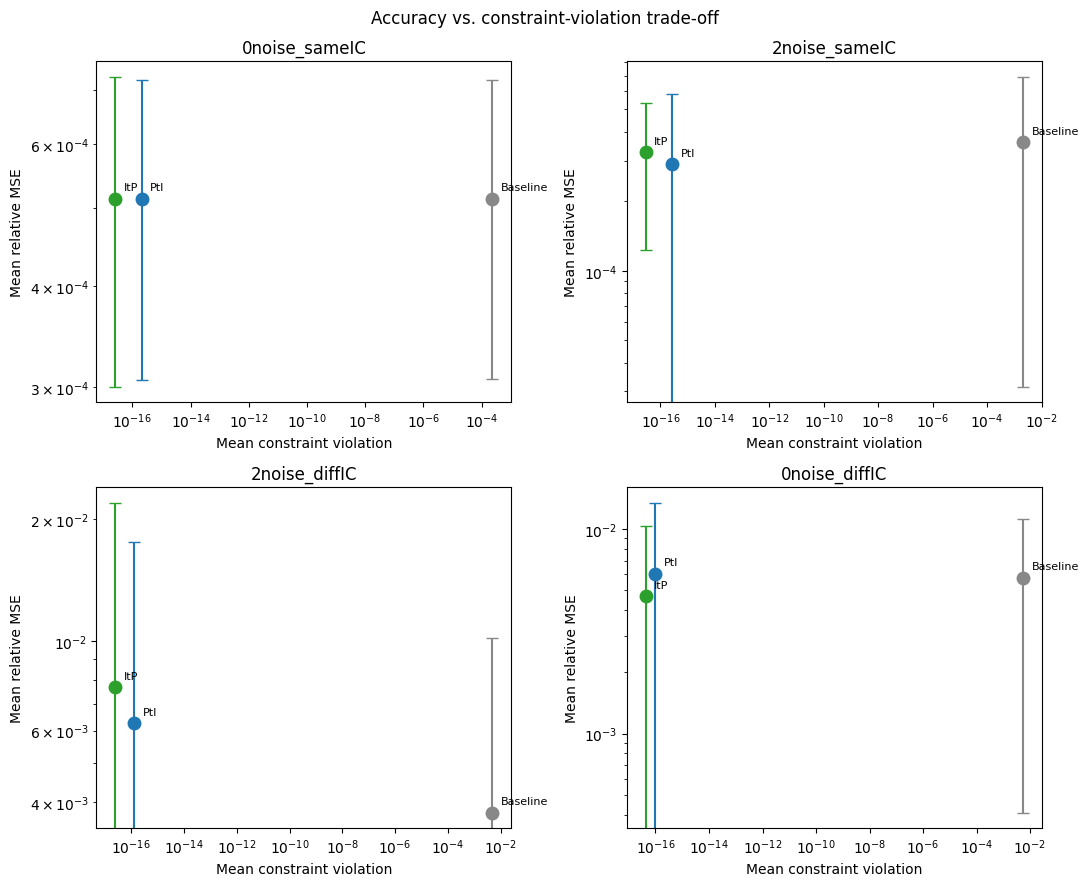

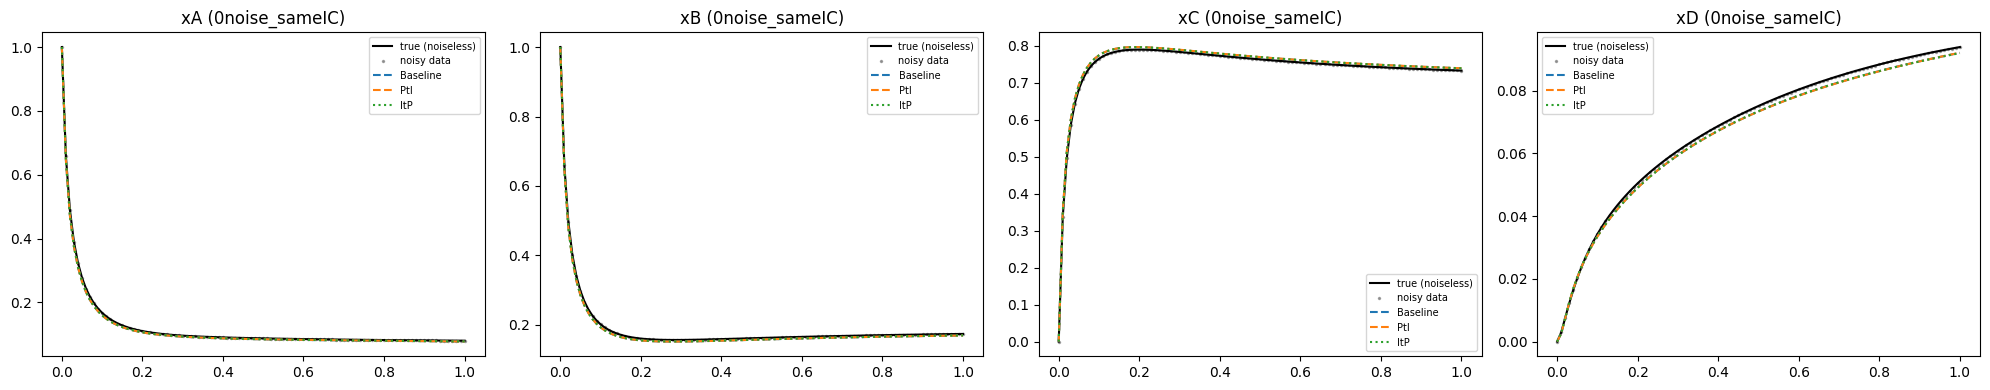

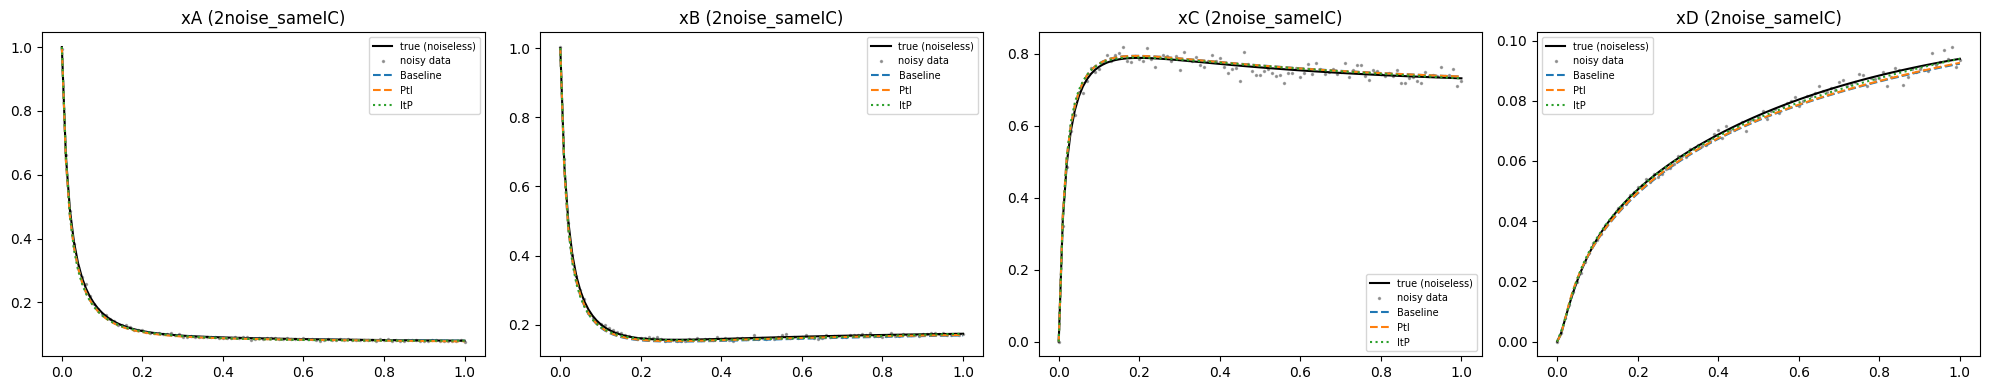

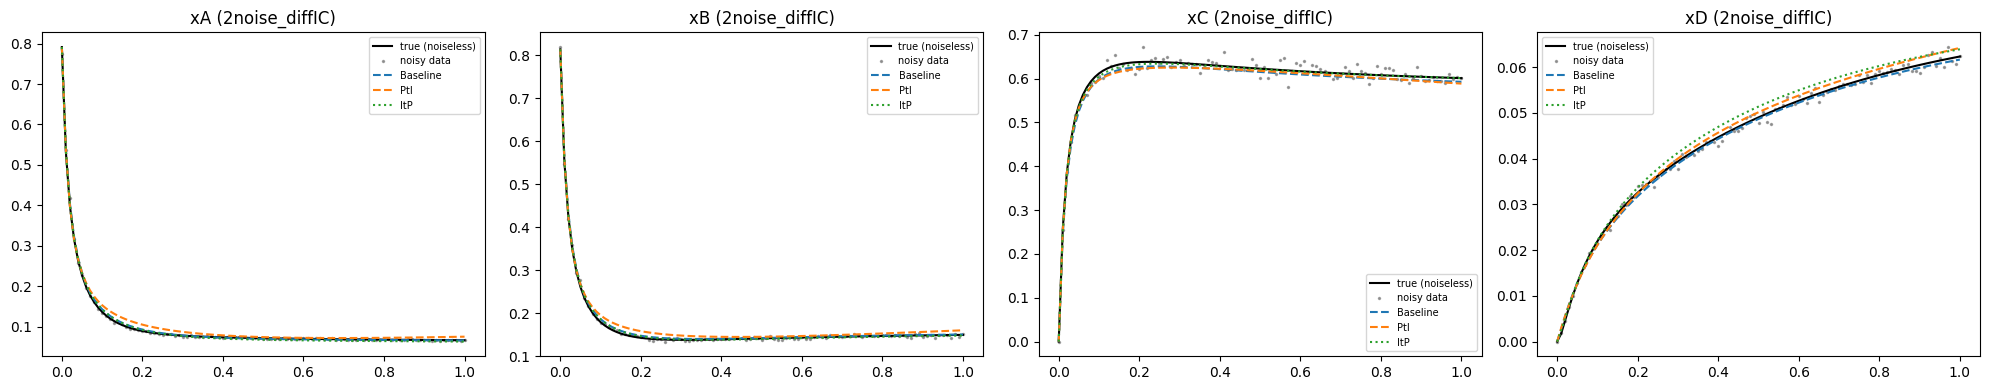

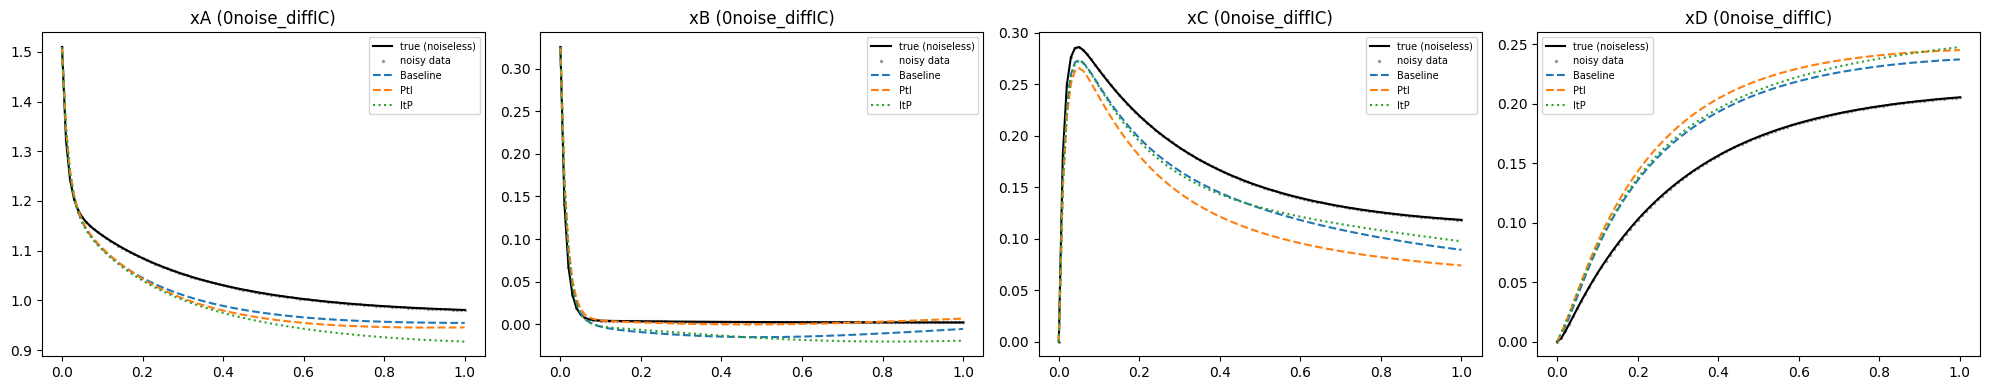


Done. All outputs saved to /mnt/user-data/outputs/
  - model_comparison_12configs_reversible.csv
  - noisy_data_constraint_violation_reversible.csv
  - loss_curves_12models_reversible.png          (train/val curves -> overfitting check)
  - summary_accuracy_violation_reversible.png    (dot-and-whisker summary, incl. noisy-data reference)
  - pareto_accuracy_vs_violation_reversible.png  (accuracy vs. constraint-violation trade-off)
  - trajectory_<condition>_reversible.png        (x4)


In [8]:
"""
Isothermal Batch Reactor with Reversible Reactions -- 12 configuration
comparison (Case 2)
========================================================================

3 methods x 4 conditions = 12 models. Same experimental design and pipeline
as Case 1 (irreversible batch reactor)
"""

import time
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
import jax.random as jr
import equinox as eqx
import optax
import optimistix as optx
from diffrax import (
    diffeqsolve, ODETerm, Kvaerno5, SaveAt, PIDController, RESULTS,
)

OUT_DIR = "/mnt/user-data/outputs"
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

CKPT_DIR = f"{OUT_DIR}/reversible_batch_ckpts"
Path(CKPT_DIR).mkdir(parents=True, exist_ok=True)

# ================== SYSTEM PARAMETERS ==================
K2F, K1R, K2R = 2.0, 1.0, 1.0
K1F_LOW, K1F_HIGH = 50.0, 60.0   # k1f ~ U[50, 60], sampled per trajectory

N_STATE = 4
labels_all = ["xA", "xB", "xC", "xD"]

# Constraint matrix: rows are h1, h2 coefficients
C_MAT = jnp.array([
    [0.0, 1.0, 1.0, 1.0],   # h1 = xB + xC + xD
    [1.0, -1.0, 0.0, 1.0],  # h2 = xA - xB + xD
])
N_CONSTR = C_MAT.shape[0]
# Physical-space Gram inverse, constant, precomputed once (used by ItP)
GRAM_PHYS_INV = jnp.linalg.inv(C_MAT @ C_MAT.T)

XA0, XB0, XC0, XD0 = 1.0, 1.0, 0.0, 0.0
x0 = jnp.array([XA0, XB0, XC0, XD0])

t_end = 1.0
N_TIME_POINTS = 101
ts = jnp.linspace(0.0, t_end, N_TIME_POINTS)

N_TRAIN, N_VAL, N_TEST = 10, 4, 6
N_TRAJ_TOTAL = N_TRAIN + N_VAL + N_TEST

# ================== FIXED ARCHITECTURE (no hyperparameter search) ==================
ARCH_WIDTH = 64
ARCH_DEPTH = 3
LEARNING_RATE = 1e-3

MAX_STEPS_FINAL = 4000
VAL_EVERY = 50
PATIENCE = 15
MAX_RETRIES = 3   # retrain from a fresh seed if the validation batch ever hits a solver failure
METHODS = ["Baseline", "PtI", "ItP"]


def reversible_batch(y, k1f):
    xA, xB, xC, xD = y
    r1 = k1f * xA * xB - K1R * xC
    r2 = K2F * xA * xC - K2R * xD
    dxA = -r1 - r2
    dxB = -r1
    dxC = r1 - r2
    dxD = r2
    return jnp.array([dxA, dxB, dxC, dxD])


rhs_true = lambda t, y, args: reversible_batch(y, args)   # args = k1f


@jax.jit
def solve_true(y0, k1f):
    sol = diffeqsolve(
        ODETerm(rhs_true), Kvaerno5(root_finder=optx.Newton(rtol=1e-4, atol=1e-4)),
        t0=0.0, t1=t_end, dt0=t_end * 1e-4, y0=y0, args=k1f, saveat=SaveAt(ts=ts),
        stepsize_controller=PIDController(rtol=1e-7, atol=1e-9), max_steps=100_000,
    )
    return sol.ys


# ================== DATASET GENERATION (per condition) ==================
def generate_dataset(seed, noise_level, ic_spread):
    key_ic = jr.PRNGKey(seed)
    if ic_spread > 0:
        scale_factors = jnp.ones((N_TRAJ_TOTAL, N_STATE))
        pert = 1.0 + ic_spread * jr.normal(key_ic, (N_TRAJ_TOTAL, 2))
        scale_factors = scale_factors.at[:, 0:2].set(pert)   # perturb xA0, xB0 only
    else:
        scale_factors = jnp.ones((N_TRAJ_TOTAL, N_STATE))
    x0_batch_all = x0[None, :] * scale_factors
    x0_batch_all = x0_batch_all.at[0].set(x0)   # first trajectory always at nominal IC
    x0_batch_all = jnp.clip(x0_batch_all, 0.0, None)

    key_k1f = jr.PRNGKey(seed + 200_000)
    k1f_all = jr.uniform(key_k1f, (N_TRAJ_TOTAL,), minval=K1F_LOW, maxval=K1F_HIGH)

    ys_true_all = jax.vmap(solve_true)(x0_batch_all, k1f_all)        # (N_TRAJ_TOTAL, 101, 4)
    C_TOTAL_per_traj = x0_batch_all @ C_MAT.T                        # (N_TRAJ_TOTAL, 2)

    key_noise = jr.PRNGKey(seed + 100_000)
    if noise_level > 0:
        noise_factors = 1.0 + noise_level * jr.normal(key_noise, ys_true_all.shape)
        ys_noisy_all = ys_true_all * noise_factors
    else:
        ys_noisy_all = ys_true_all

    idx_train = slice(0, N_TRAIN)
    idx_val = slice(N_TRAIN, N_TRAIN + N_VAL)
    idx_test = slice(N_TRAIN + N_VAL, N_TRAJ_TOTAL)

    x0_train, x0_val, x0_test = (x0_batch_all[idx_train], x0_batch_all[idx_val],
                                  x0_batch_all[idx_test])
    ys_true_train, ys_true_val, ys_true_test = (ys_true_all[idx_train],
                                                 ys_true_all[idx_val],
                                                 ys_true_all[idx_test])
    ys_noisy_train, ys_noisy_val, ys_noisy_test = (ys_noisy_all[idx_train],
                                                    ys_noisy_all[idx_val],
                                                    ys_noisy_all[idx_test])
    C_TOTAL_train = C_TOTAL_per_traj[idx_train]
    C_TOTAL_val = C_TOTAL_per_traj[idx_val]
    C_TOTAL_test = C_TOTAL_per_traj[idx_test]
    k1f_train, k1f_val, k1f_test = k1f_all[idx_train], k1f_all[idx_val], k1f_all[idx_test]

    # normalization stats from noisy TRAIN data only (no leakage)
    y_mean = ys_noisy_train.reshape(-1, N_STATE).mean(axis=0)
    y_std = jnp.maximum(ys_noisy_train.reshape(-1, N_STATE).std(axis=0),
                         1e-3 * jnp.abs(y_mean) + 1e-12)

    def normalize(y):
        return (y - y_mean) / y_std

    def denormalize(z):
        return z * y_std + y_mean

    z0_train, z0_val, z0_test = normalize(x0_train), normalize(x0_val), normalize(x0_test)
    zs_noisy_train = normalize(ys_noisy_train)
    zs_noisy_val = normalize(ys_noisy_val)

    return dict(
        noise_level=noise_level, ic_spread=ic_spread,
        x0_batch_all=x0_batch_all, ys_true_all=ys_true_all, ys_noisy_all=ys_noisy_all,
        k1f_all=k1f_all, k1f_train=k1f_train, k1f_val=k1f_val, k1f_test=k1f_test,
        z0_train=z0_train, z0_val=z0_val, z0_test=z0_test,
        zs_noisy_train=zs_noisy_train, zs_noisy_val=zs_noisy_val,
        ys_true_train=ys_true_train, ys_true_val=ys_true_val, ys_true_test=ys_true_test,
        ys_noisy_train=ys_noisy_train, ys_noisy_val=ys_noisy_val, ys_noisy_test=ys_noisy_test,
        C_TOTAL_train=C_TOTAL_train, C_TOTAL_val=C_TOTAL_val, C_TOTAL_test=C_TOTAL_test,
        y_mean=y_mean, y_std=y_std, normalize=normalize, denormalize=denormalize,
    )


# ================== MODEL DEFINITIONS ==================
class NeuralODE(eqx.Module):
    mlp: eqx.nn.MLP

    def __init__(self, n_state, width, depth, key, activation=jax.nn.softplus):
        mlp = eqx.nn.MLP(n_state, n_state, width, depth, activation=activation, key=key)
        last = mlp.layers[-1]
        last = eqx.tree_at(lambda l: (l.weight, l.bias), last,
                            (jnp.zeros_like(last.weight), jnp.zeros_like(last.bias)))
        self.mlp = eqx.tree_at(lambda m: m.layers[-1], mlp, last)

    def __call__(self, t, z, args):
        return self.mlp(z)


class ProjectedNeuralODE(eqx.Module):
    mlp: eqx.nn.MLP
    c_norm: jnp.ndarray          # (N_CONSTR, n_state), constant -- see stop_gradient below
    gram_norm_inv: jnp.ndarray   # (N_CONSTR, N_CONSTR), constant

    def __init__(self, n_state, width, depth, key, y_std, activation=jax.nn.softplus):
        mlp = eqx.nn.MLP(n_state, n_state, width, depth, activation=activation, key=key)
        last = mlp.layers[-1]
        last = eqx.tree_at(lambda l: (l.weight, l.bias), last,
                            (jnp.zeros_like(last.weight), jnp.zeros_like(last.bias)))
        self.mlp = eqx.tree_at(lambda m: m.layers[-1], mlp, last)
        c_norm = C_MAT * y_std[None, :]
        self.c_norm = c_norm
        self.gram_norm_inv = jnp.linalg.inv(c_norm @ c_norm.T)

    def __call__(self, t, z, args):
        raw = self.mlp(z)
        c = jax.lax.stop_gradient(self.c_norm)
        ginv = jax.lax.stop_gradient(self.gram_norm_inv)
        lam = ginv @ (c @ raw)
        correction = c.T @ lam
        return raw - correction


def make_model(method, seed_key, y_std):
    if method == "PtI":
        return ProjectedNeuralODE(N_STATE, ARCH_WIDTH, ARCH_DEPTH, seed_key, y_std)
    return NeuralODE(N_STATE, ARCH_WIDTH, ARCH_DEPTH, seed_key)  # Baseline / ItP


def predict_with_status(model, ts_, z0):
    sol = diffeqsolve(
        ODETerm(model), Kvaerno5(root_finder=optx.Newton(rtol=1e-4, atol=1e-4)),
        t0=ts_[0], t1=ts_[-1], dt0=(ts_[1] - ts_[0]) * 1e-3, y0=z0, saveat=SaveAt(ts=ts_),
        stepsize_controller=PIDController(rtol=1e-5, atol=1e-7), max_steps=50_000,
        throw=False,
    )
    failed = sol.result != RESULTS.successful
    ys = jnp.where(failed, jnp.full_like(sol.ys, 1e3), sol.ys)
    ys = jnp.nan_to_num(ys, nan=1e3, posinf=1e3, neginf=-1e3)
    return ys, failed


def predict(model, ts_, z0):
    ys, _ = predict_with_status(model, ts_, z0)
    return ys


batched_predict = jax.vmap(predict, in_axes=(None, None, 0))
batched_predict_with_status = jax.vmap(predict_with_status, in_axes=(None, None, 0))


def loss_fn(model, ts_, z0_batch, z_target_batch):
    z_pred = batched_predict(model, ts_, z0_batch)
    return jnp.mean((z_pred - z_target_batch) ** 2)


loss_and_grad = eqx.filter_value_and_grad(loss_fn)


# ================== TRAINING WITH EARLY STOPPING + FAILURE TRACKING ==================
def train_model_early_stopping(model, lr, z0_tr, z_target_tr, z0_va, z_target_va,
                                max_steps=8000, val_every=50, patience=15,
                                verbose=True, model_name=""):
    optimizer = optax.chain(optax.clip_by_global_norm(1.0), optax.adam(lr))
    opt_state = optimizer.init(eqx.filter(model, eqx.is_inexact_array))

    @eqx.filter_jit
    def step(model, opt_state):
        loss, grads = loss_and_grad(model, ts, z0_tr, z_target_tr)
        updates, opt_state = optimizer.update(grads, opt_state, model)
        model = eqx.apply_updates(model, updates)
        return model, opt_state, loss

    train_losses = []
    val_losses, val_steps, val_fail_counts = [], [], []
    best_val = float("inf")
    best_model = model
    best_step = 0
    steps_since_improve = 0
    t0 = time.time()
    final_step = 0

    for i in range(1, max_steps + 1):
        model, opt_state, loss = step(model, opt_state)
        train_losses.append(float(loss))
        final_step = i

        if i % val_every == 0 or i == 1:
            v = float(loss_fn(model, ts, z0_va, z_target_va))
            _, failed_va = batched_predict_with_status(model, ts, z0_va)
            n_fail = int(jnp.sum(failed_va))
            val_losses.append(v)
            val_steps.append(i)
            val_fail_counts.append(n_fail)

            if n_fail > 0 and verbose:
                print(f"  [{model_name}] step {i}: {n_fail} validation "
                      f"trajectory(ies) hit a solver failure")

            if v < best_val - 1e-9:
                best_val = v
                best_model = model
                best_step = i
                steps_since_improve = 0
            else:
                steps_since_improve += 1

            if verbose and (i % (val_every * 4) == 0 or i == 1):
                print(f"  [{model_name}] step {i:5d}  train {loss:.4e}  "
                      f"val {v:.4e}  best {best_val:.4e} (@{best_step})")

            if steps_since_improve >= patience:
                if verbose:
                    print(f"  [{model_name}] early stop at step {i} "
                          f"(best val {best_val:.4e} at step {best_step})")
                break

    train_time = time.time() - t0
    history = dict(train_losses=train_losses, val_losses=val_losses, val_steps=val_steps,
                    val_fail_counts=val_fail_counts, best_step=best_step, best_val=best_val,
                    stopped_at=final_step)
    return best_model, history, train_time


def train_with_retries(method, cname, ds, model_key_counter, name):
    attempts = []
    for attempt in range(MAX_RETRIES):
        seed_key = jr.PRNGKey(1000 + model_key_counter * 100 + attempt)
        model = make_model(method, seed_key, ds["y_std"])
        if attempt > 0:
            print(f"  [{name}] retry {attempt+1}/{MAX_RETRIES} with a fresh seed "
                  f"(previous attempt hit solver failures)")
        trained_model, history, train_time = train_model_early_stopping(
            model, LEARNING_RATE, ds["z0_train"], ds["zs_noisy_train"],
            ds["z0_val"], ds["zs_noisy_val"],
            max_steps=MAX_STEPS_FINAL, val_every=VAL_EVERY, patience=PATIENCE,
            verbose=True, model_name=name,
        )
        total_fail = int(sum(history["val_fail_counts"]))
        attempts.append((trained_model, history, train_time, total_fail))
        print(f"  -> [{name}] attempt {attempt+1}: stopped at step {history['stopped_at']}, "
              f"best_val={history['best_val']:.4e}, total val solver failures={total_fail}")
        if total_fail == 0:
            return trained_model, history, train_time, attempt, False

    # All attempts had failures: keep the best (lowest best_val) and flag it.
    attempts.sort(key=lambda a: a[1]["best_val"])
    trained_model, history, train_time, total_fail = attempts[0]
    print(f"  [{name}] WARNING: solver failures persisted in all {MAX_RETRIES} attempts; "
          f"keeping the attempt with the lowest best_val (best_val={history['best_val']:.4e}, "
          f"{total_fail} val solver failures). Treat this cell's results with caution.")
    return trained_model, history, train_time, MAX_RETRIES - 1, True


def project_state(y_row, target):
    """ItP post-hoc projection: minimum-norm correction in PHYSICAL space so
    that C_MAT @ y_row == target for both constraints simultaneously."""
    c_pred = C_MAT @ y_row
    lam = GRAM_PHYS_INV @ (c_pred - target)
    return y_row - C_MAT.T @ lam


def project_trajectory(y_traj, target):
    return jax.vmap(lambda row: project_state(row, target))(y_traj)


def rel_mse(y_pred, y_true):
    mean_sq_true = jnp.mean(y_true ** 2, axis=(0, 1))
    eps = 1e-8
    per_traj = jnp.mean((y_pred - y_true) ** 2 / (mean_sq_true[None, None, :] + eps),
                         axis=(1, 2))
    return per_traj


def rmse(y_pred, y_true):
    """Per-trajectory root mean squared error (unnormalized, physical units)."""
    per_traj = jnp.sqrt(jnp.mean((y_pred - y_true) ** 2, axis=(1, 2)))
    return per_traj


def constraint_violation(y_pred, target):
    """target: (batch, N_CONSTR). Returns mean |violation| per trajectory,
    averaged over both time and the two constraints."""
    inv = jnp.einsum('btj,cj->btc', y_pred, C_MAT)
    diff = jnp.abs(inv - target[:, None, :])
    return jnp.mean(diff, axis=(1, 2))


# ================== 4 CONDITIONS ==================
CONDITIONS = [
    dict(cond_name="0noise_sameIC", noise_level=0.00, ic_spread=0.00, seed=10),
    dict(cond_name="2noise_sameIC", noise_level=0.02, ic_spread=0.00, seed=20),
    dict(cond_name="2noise_diffIC", noise_level=0.02, ic_spread=0.40, seed=30),
    dict(cond_name="0noise_diffIC", noise_level=0.00, ic_spread=0.40, seed=40),
]

print("Generating datasets for all 4 conditions...")
datasets = {}
noisy_violation = {}
for cond in CONDITIONS:
    cname = cond["cond_name"]
    print(f"  {cname}: noise={cond['noise_level']*100:.0f}%, "
          f"IC spread={cond['ic_spread']*100:.0f}%")
    ds = generate_dataset(cond["seed"], cond["noise_level"], cond["ic_spread"])
    datasets[cname] = ds
    noisy_violation[cname] = constraint_violation(ds["ys_noisy_test"], ds["C_TOTAL_test"])

print(f"\nArchitecture used for ALL 12 models (fixed, no search): "
      f"width={ARCH_WIDTH}, depth={ARCH_DEPTH}, lr={LEARNING_RATE:.2e}")


def ckpt_path(cname, method):
    return f"{CKPT_DIR}/{cname}__{method}"


def save_checkpoint(cname, method, model, history, train_time, y_pred_test, n_attempts, flagged):
    path = ckpt_path(cname, method)
    eqx.tree_serialise_leaves(path + ".eqx", model)
    with open(path + ".pkl", "wb") as f:
        pickle.dump({
            "history": history, "train_time": train_time,
            "y_pred_test": np.array(y_pred_test),
            "n_attempts": n_attempts, "flagged": flagged,
        }, f)


def load_checkpoint(cname, method, model_template):
    path = ckpt_path(cname, method)
    if not (Path(path + ".eqx").exists() and Path(path + ".pkl").exists()):
        return None
    with open(path + ".pkl", "rb") as f:
        meta = pickle.load(f)

    if "val_fail_counts" not in meta["history"] or "flagged" not in meta:
        print(f"  [{cname}/{method}] checkpoint predates failure-tracking, retraining.")
        return None
    model = eqx.tree_deserialise_leaves(path + ".eqx", model_template)
    return (model, meta["history"], meta["train_time"], jnp.array(meta["y_pred_test"]),
            meta["n_attempts"], meta["flagged"])


# ================== TRAINING LOOP: 12 MODELS ==================
all_models, all_histories, all_preds = {}, {}, {}
results_rows = []
model_key_counter = 0

for cond in CONDITIONS:
    cname = cond["cond_name"]
    ds = datasets[cname]
    print(f"\n{'='*70}\nCONDITION: {cname}  "
          f"(noise={cond['noise_level']*100:.0f}%, IC spread={cond['ic_spread']*100:.0f}%)\n{'='*70}")

    for method in METHODS:
        model_key_counter += 1
        name = f"{cname} / {method}"
        model_template = make_model(method, jr.PRNGKey(0), ds["y_std"])

        cached = load_checkpoint(cname, method, model_template)
        if cached is not None:
            print(f"  [{name}] checkpoint found, skipping training.")
            trained_model, history, train_time, y_pred_test, n_attempts, flagged = cached
        else:
            print(f"\n--- Training: {name} ---")
            trained_model, history, train_time, n_attempts, flagged = train_with_retries(
                method, cname, ds, model_key_counter, name)

            z_pred_test = batched_predict(trained_model, ts, ds["z0_test"])
            y_pred_test = ds["denormalize"](z_pred_test)
            if method == "ItP":
                y_pred_test = jax.vmap(project_trajectory)(y_pred_test, ds["C_TOTAL_test"])
            save_checkpoint(cname, method, trained_model, history, train_time,
                             y_pred_test, n_attempts, flagged)
            print(f"  -> checkpoint saved: {ckpt_path(cname, method)}")

        all_models[(cname, method)] = trained_model
        all_histories[(cname, method)] = history
        all_preds[(cname, method)] = y_pred_test

        rel_mse_vals = rel_mse(y_pred_test, ds["ys_true_test"])
        rmse_vals = rmse(y_pred_test, ds["ys_true_test"])
        viol_vals = constraint_violation(y_pred_test, ds["C_TOTAL_test"])
        results_rows.append({
            "condition": cname, "method": method,
            "noise_level": cond["noise_level"], "ic_spread": cond["ic_spread"],
            "rel_mse_mean": float(jnp.mean(rel_mse_vals)), "rel_mse_std": float(jnp.std(rel_mse_vals)),
            "rmse_mean": float(jnp.mean(rmse_vals)), "rmse_std": float(jnp.std(rmse_vals)),
            "violation_mean": float(jnp.mean(viol_vals)), "violation_std": float(jnp.std(viol_vals)),
            "best_step": history["best_step"], "stopped_at": history["stopped_at"],
            "train_time_s": train_time, "n_attempts": n_attempts + 1, "flagged": flagged,
        })

results_df = pd.DataFrame(results_rows)
print("\n\n=== FULL 12-MODEL COMPARISON (test set) ===")
print(results_df.to_string(index=False))
results_df.to_csv(f"{OUT_DIR}/model_comparison_12configs_reversible.csv", index=False)

if results_df["flagged"].any():
    print("\nWARNING: the following cells kept a run with solver failures despite "
          f"{MAX_RETRIES} retries -- treat with caution:")
    print(results_df[results_df["flagged"]][["condition", "method"]].to_string(index=False))

noisy_violation_rows = [
    {"condition": c, "violation_mean": float(jnp.mean(noisy_violation[c])),
     "violation_std": float(jnp.std(noisy_violation[c]))}
    for c in noisy_violation
]
pd.DataFrame(noisy_violation_rows).to_csv(
    f"{OUT_DIR}/noisy_data_constraint_violation_reversible.csv", index=False)

# ================== PHYSICAL VALIDITY CHECK (non-negativity) ==================
print("\n=== Physical validity check: most negative predicted value per channel ===")
NEG_TOL = -1e-6
any_negative = False
for cond in CONDITIONS:
    cname = cond["cond_name"]
    for method in METHODS:
        mins = np.array(jnp.min(all_preds[(cname, method)], axis=(0, 1)))
        flags = [f"{labels_all[i]}={mins[i]:.3e}" +
                 ("  <-- NEGATIVE" if mins[i] < NEG_TOL else "")
                 for i in range(N_STATE)]
        if any(mins < NEG_TOL):
            any_negative = True
            print(f"  {cname:15s} {method:10s} " + ", ".join(flags))
if not any_negative:
    print("  No channel dropped below zero (tolerance {:.0e}) in any model.".format(NEG_TOL))

# ================== TRAIN/VAL LOSS CURVES (overfitting check) -- 4x3 grid ==================
fig, axes = plt.subplots(4, 3, figsize=(16, 18))
for row, cond in enumerate(CONDITIONS):
    cname = cond["cond_name"]
    for col, method in enumerate(METHODS):
        ax = axes[row, col]
        h = all_histories[(cname, method)]
        ax.plot(range(1, len(h["train_losses"]) + 1), h["train_losses"],
                label="train_loss", alpha=0.7, linewidth=1)
        ax.plot(h["val_steps"], h["val_losses"], "o-", label="val_loss",
                markersize=3, linewidth=1.5)
        ax.axvline(h["best_step"], color="red", linestyle="--", linewidth=1,
                    label=f"best (step {h['best_step']})")
        ax.set(yscale="log", title=f"{cname} / {method}", xlabel="step", ylabel="loss")
        ax.legend(fontsize=6)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/loss_curves_12models_reversible.png", dpi=150)
plt.show()

# ================== SUMMARY DOT-AND-WHISKER PLOT (mean +/- std) ==================
METHOD_COLORS = {"Baseline": "#888888", "PtI": "#1f77b4", "ItP": "#2ca02c"}
cond_names = [c["cond_name"] for c in CONDITIONS]
x = np.arange(len(cond_names))
offsets = {"Baseline": -0.15, "PtI": 0.0, "ItP": 0.15}

fig_s, axes_s = plt.subplots(2, 1, figsize=(9, 8), sharex=True)

for method in METHODS:
    means = [results_df[(results_df.condition == c) & (results_df.method == method)]
             ["rel_mse_mean"].values[0] for c in cond_names]
    stds = [results_df[(results_df.condition == c) & (results_df.method == method)]
            ["rel_mse_std"].values[0] for c in cond_names]
    axes_s[0].errorbar(x + offsets[method], means, yerr=stds, fmt="o", markersize=7,
                        capsize=4, color=METHOD_COLORS[method], label=method)
axes_s[0].set(ylabel="Relative MSE", yscale="log", title="Prediction accuracy")
axes_s[0].legend()

for method in METHODS:
    means = [results_df[(results_df.condition == c) & (results_df.method == method)]
             ["violation_mean"].values[0] for c in cond_names]
    stds = [results_df[(results_df.condition == c) & (results_df.method == method)]
            ["violation_std"].values[0] for c in cond_names]
    axes_s[1].errorbar(x + offsets[method], means, yerr=stds, fmt="o", markersize=7,
                        capsize=4, color=METHOD_COLORS[method], label=method)

noisy_means = [float(jnp.mean(noisy_violation[c])) for c in cond_names]
noisy_stds = [float(jnp.std(noisy_violation[c])) for c in cond_names]
axes_s[1].errorbar(x, noisy_means, yerr=noisy_stds, fmt="k*", markersize=12,
                    capsize=4, label="Noisy data (reference)")

axes_s[1].set(ylabel="Mean |constraint violation| (h1, h2)", yscale="log",
              title="Constraint violation")
axes_s[1].set_xticks(x)
axes_s[1].set_xticklabels(cond_names, rotation=15)
axes_s[1].legend()

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/summary_accuracy_violation_reversible.png", dpi=200)
plt.show()

# ================== PARETO / TRADE-OFF PLOT: accuracy vs. constraint violation ==================
fig_p, axes_p = plt.subplots(2, 2, figsize=(11, 9))

for ax, cond in zip(axes_p.flat, CONDITIONS):
    cname = cond["cond_name"]
    for method in METHODS:
        row = results_df[(results_df.condition == cname) & (results_df.method == method)].iloc[0]
        ax.errorbar(
            row["violation_mean"], row["rel_mse_mean"], yerr=row["rel_mse_std"],
            fmt="o", markersize=9, capsize=4, color=METHOD_COLORS[method], label=method,
        )
        ax.annotate(method, (row["violation_mean"], row["rel_mse_mean"]),
                    textcoords="offset points", xytext=(6, 6), fontsize=8)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Mean constraint violation")
    ax.set_ylabel("Mean relative MSE")
    ax.set_title(cname)

fig_p.suptitle("Accuracy vs. constraint-violation trade-off")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/pareto_accuracy_vs_violation_reversible.png", dpi=200)
plt.show()

# ================== EXAMPLE TRAJECTORY PLOTS (one per condition) ==================
for cond in CONDITIONS:
    cname = cond["cond_name"]
    ds = datasets[cname]
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    for idx, varname in enumerate(labels_all):
        ax = axes[idx]
        ax.plot(ts, ds["ys_true_test"][0, :, idx], "k-", label="true (noiseless)")
        ax.plot(ts, ds["ys_noisy_test"][0, :, idx], "k.", alpha=0.3, markersize=3,
                label="noisy data")
        for method, style in zip(METHODS, ["--", "--", ":"]):
            ax.plot(ts, all_preds[(cname, method)][0, :, idx], style, label=method)
        ax.legend(fontsize=7)
        ax.set(title=f"{varname} ({cname})")
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/trajectory_{cname}_reversible.png", dpi=150)
    plt.show()

print(f"\nDone. All outputs saved to {OUT_DIR}/")
print("  - model_comparison_12configs_reversible.csv")
print("  - noisy_data_constraint_violation_reversible.csv")
print("  - loss_curves_12models_reversible.png          (train/val curves -> overfitting check)")
print("  - summary_accuracy_violation_reversible.png    (dot-and-whisker summary, incl. noisy-data reference)")
print("  - pareto_accuracy_vs_violation_reversible.png  (accuracy vs. constraint-violation trade-off)")
print("  - trajectory_<condition>_reversible.png        (x4)")

In [9]:
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import jax.numpy as jnp
import jax.random as jr

OUT_DIR = "/mnt/user-data/outputs"
CKPT_DIR = f"{OUT_DIR}/reversible_batch_ckpts"

N_STATE = 4
labels_all = ["xA", "xB", "xC", "xD"]
XA0, XB0, XC0, XD0 = 1.0, 1.0, 0.0, 0.0
x0 = jnp.array([XA0, XB0, XC0, XD0])
N_TRAIN, N_VAL, N_TEST = 10, 4, 6
N_TRAJ_TOTAL = N_TRAIN + N_VAL + N_TEST

CONDITIONS = [
    dict(cond_name="0noise_sameIC", noise_level=0.00, ic_spread=0.00, seed=10),
    dict(cond_name="2noise_sameIC", noise_level=0.02, ic_spread=0.00, seed=20),
    dict(cond_name="2noise_diffIC", noise_level=0.02, ic_spread=0.40, seed=30),
    dict(cond_name="0noise_diffIC", noise_level=0.00, ic_spread=0.40, seed=40),
]
METHODS = ["Baseline", "PtI", "ItP"]

NEG_TOL = -1e-6   # anything below this counts as a real negative, not float noise


def get_test_ic(seed, ic_spread):
    """Reproduces exactly the IC sampling in generate_dataset() -- only the
    (cheap) IC step, no ODE solve needed for this diagnostic."""
    key_ic = jr.PRNGKey(seed)
    if ic_spread > 0:
        scale_factors = jnp.ones((N_TRAJ_TOTAL, N_STATE))
        pert = 1.0 + ic_spread * jr.normal(key_ic, (N_TRAJ_TOTAL, 2))
        scale_factors = scale_factors.at[:, 0:2].set(pert)
    else:
        scale_factors = jnp.ones((N_TRAJ_TOTAL, N_STATE))
    x0_batch_all = x0[None, :] * scale_factors
    x0_batch_all = x0_batch_all.at[0].set(x0)
    x0_batch_all = jnp.clip(x0_batch_all, 0.0, None)
    idx_test = slice(N_TRAIN + N_VAL, N_TRAJ_TOTAL)
    return np.array(x0_batch_all[idx_test])


neg_rows = []
for cond in CONDITIONS:
    cname = cond["cond_name"]
    x0_test = get_test_ic(cond["seed"], cond["ic_spread"])
    ic_dist = np.linalg.norm(x0_test - np.array(x0), axis=1)

    for method in METHODS:
        path = f"{CKPT_DIR}/{cname}__{method}.pkl"
        if not Path(path).exists():
            print(f"  [skip] no checkpoint found for {cname}/{method} at {path}")
            continue
        with open(path, "rb") as f:
            meta = pickle.load(f)
        preds = np.array(meta["y_pred_test"])  # (N_TEST, N_TIME_POINTS, 4)
        n_time = preds.shape[1]

        for traj_idx in range(preds.shape[0]):
            for ch in range(N_STATE):
                series = preds[traj_idx, :, ch]
                neg_mask = series < NEG_TOL
                n_neg = int(neg_mask.sum())
                if n_neg == 0:
                    continue
                neg_time_idxs = np.where(neg_mask)[0]
                neg_rows.append({
                    "condition": cname, "method": method, "test_traj_idx": traj_idx,
                    "channel": labels_all[ch],
                    "frac_timesteps_negative": n_neg / n_time,
                    "min_value": float(series.min()),
                    "frac_negative_in_first_half": float(np.mean(neg_time_idxs < (n_time // 2))),
                    "ic_distance_from_nominal": float(ic_dist[traj_idx]),
                })

neg_df = pd.DataFrame(neg_rows)
out_csv = f"{OUT_DIR}/negative_concentration_report_reversible.csv"
neg_df.to_csv(out_csv, index=False)

print(f"Saved detailed per-trajectory report to {out_csv}\n")
if len(neg_df) == 0:
    print("No negative values (below tolerance) found in any test trajectory/channel/model.")
else:
    print(neg_df.to_string(index=False))

    print("\n=== SUMMARY (by condition / method) ===")
    summary = neg_df.groupby(["condition", "method"]).agg(
        n_channel_traj_pairs_negative=("channel", "count"),
        worst_min_value=("min_value", "min"),
        mean_frac_timesteps_negative=("frac_timesteps_negative", "mean"),
        mean_frac_negative_in_first_half=("frac_negative_in_first_half", "mean"),
    )
    print(summary.to_string())

    corr = neg_df[["ic_distance_from_nominal", "min_value"]].corr().iloc[0, 1]
    print(f"\nCorrelation between IC distance-from-nominal and min predicted value: {corr:.3f}")
    print("(negative correlation => ICs farther from nominal tend to produce deeper negative dips)")

    print("\n=== SUMMARY (by channel, across all conditions/methods) ===")
    by_channel = neg_df.groupby("channel").agg(
        n_negative_cases=("channel", "count"),
        worst_min_value=("min_value", "min"),
    )
    print(by_channel.to_string())

Saved detailed per-trajectory report to /mnt/user-data/outputs/negative_concentration_report_reversible.csv

    condition   method  test_traj_idx channel  frac_timesteps_negative  min_value  frac_negative_in_first_half  ic_distance_from_nominal
2noise_diffIC Baseline              2      xA                 0.900990  -0.023148                     0.439560                  0.941640
2noise_diffIC Baseline              2      xD                 0.990099  -0.018806                     0.490000                  0.941640
2noise_diffIC      PtI              2      xA                 0.821782  -0.034203                     0.385542                  0.941640
2noise_diffIC      PtI              2      xD                 0.990099  -0.028894                     0.490000                  0.941640
2noise_diffIC      ItP              2      xA                 0.930693  -0.041725                     0.457447                  0.941640
2noise_diffIC      ItP              2      xD                 0.99009